# Laboratorio 01 - Introducción al Machine Learning

**Nombre del alumno**: Nisse Maximiliano Martinez Pardo \
**Link a github del laboratorio**: https://github.com/nmmartinezp/SIS420-Inteligencia-Artifical---NMMP/tree/master/Laboratorios/Laboratorio%2001 \
**Link de dataset**: https://www.kaggle.com/datasets/nabeelqureshitiii/student-performance-dataset?resource=download

## Contexto del dataset

Este conjunto de datos contiene 1.000.000 de filas de datos realistas sobre el rendimiento de los estudiantes. Cada fila representa a un estudiante con características como horas de estudio, asistencia, participación en clase y calificación final. El conjunto de datos es pequeño, claro y está estructurado para que sea fácil de usar para principiantes.

## Librerias usadas

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Cargar datos del csv - Student Performance

In [8]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [14]:
# Se utilizara BÚSQUEDA POR FUERZA BRUTA con 2 bucles anidados que
# prueban diferentes combinaciones de b y w, calculando el error
# de cada combinación y quedándose con la que menor error produzca

df = pd.read_csv('/content/gdrive/MyDrive/Courses/SIS420 Inteligencia artidicial I/Datasets/student_performance.csv')

df = df.head(100)
print(f"Total de estudiantes: {len(df)}")

X = df['weekly_self_study_hours'].values  # Horas de estudio
y = df['total_score'].values              # Puntaje total

print(f"Horas de estudio - Min: {X.min():.1f}, Max: {X.max():.1f}, Media: {X.mean():.2f}")
print(f"Puntaje total - Min: {y.min():.1f}, Max: {y.max():.1f}, Media: {y.mean():.2f}")

Total de estudiantes: 100
Horas de estudio - Min: 0.0, Max: 28.0, Media: 14.31
Puntaje total - Min: 47.4, Max: 100.0, Media: 82.69


## Busqueda de parametros

In [16]:
# b: el puntaje base (con 0 horas de estudio) debe estar entre 0 y 100
# w: la pendiente (cambio en puntaje por hora) debe ser razonable

b_min = -50.0    # Límite inferior para b
b_max = 100.0    # Límite superior para b
b_step = 0.5     # Paso para b (qué tan fino buscamos)

w_min = -5.0     # Límite inferior para w
w_max = 5.0      # Límite superior para w
w_step = 0.05    # Paso para w

print(f"Rango de b: [{b_min}, {b_max}] con paso {b_step}")
print(f"Rango de w: [{w_min}, {w_max}] con paso {w_step}")

# variables para el mejor resultado
mejor_error = float('inf')  # Inicia con un valor muy grande
mejor_b = 0
mejor_w = 0

# Contador de combinaciones probadas
combinaciones_probadas = 0

# recorremos todos los valores de b
b_actual = b_min
while b_actual <= b_max:

    # recorremos todos los valores de w
    w_actual = w_min
    while w_actual <= w_max:

        combinaciones_probadas = combinaciones_probadas + 1

        # Calcular el error de esta combinación (b, w)
        error_actual = 0.0

        # Recorremos todos los datos para calcular el error
        i = 0
        while i < len(X):
            y_pred = b_actual + w_actual * X[i]
            diff = y[i] - y_pred
            error_actual = error_actual + diff * diff

            i = i + 1

        # Dividimos entre n para obtener el error cuadrático medio
        error_actual = error_actual / len(X)

        if error_actual < mejor_error:
            mejor_error = error_actual
            mejor_b = b_actual
            mejor_w = w_actual

        w_actual = w_actual + w_step

    b_actual = b_actual + b_step

print(f"\nCombinaciones probadas: {combinaciones_probadas:,}")
print(f"Mejor b (intercepto): {mejor_b:.4f}")
print(f"Mejor w (pendiente): {mejor_w:.6f}")
print(f"Error cuadrático medio: {mejor_error:.4f}")
print(f"\nEcuación final: y = {mejor_b:.4f} + {mejor_w:.6f} * x")


Rango de b: [-50.0, 100.0] con paso 0.5
Rango de w: [-5.0, 5.0] con paso 0.05

Combinaciones probadas: 60,501
Mejor b (intercepto): 54.0000
Mejor w (pendiente): 2.000000
Error cuadrático medio: 77.4759

Ecuación final: y = 54.0000 + 2.000000 * x


• Intercepto (b = 54.00): Puntaje base esperado con 0 horas de estudio.
• Pendiente (w = 2.0000): Por cada hora adicional de estudio semanal,
  el puntaje total aumenta en promedio 2.00 puntos.


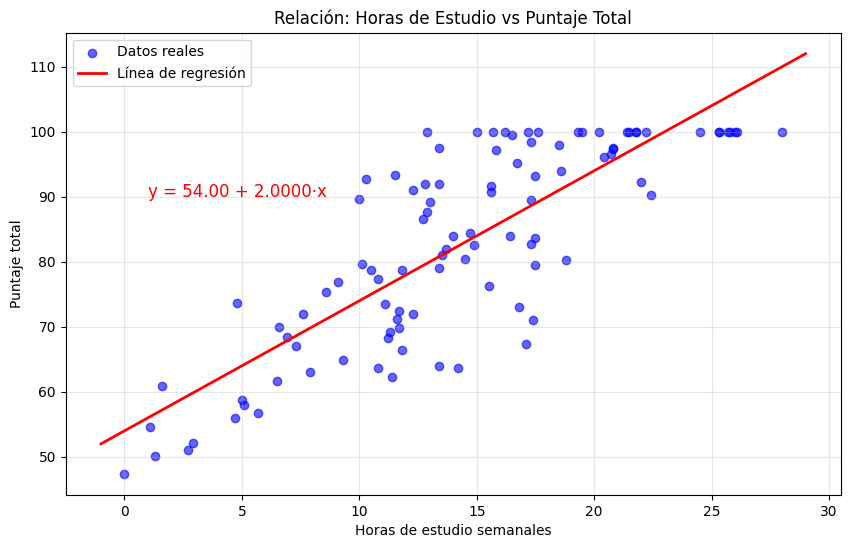

In [17]:
print(f"• Intercepto (b = {mejor_b:.2f}): Puntaje base esperado con 0 horas de estudio.")
print(f"• Pendiente (w = {mejor_w:.4f}): Por cada hora adicional de estudio semanal,")
print(f"  el puntaje total aumenta en promedio {mejor_w:.2f} puntos.")

# Generamos la línea de regresión para el rango de datos
x_line = np.linspace(X.min() - 1, X.max() + 1, 100)
y_line = mejor_b + mejor_w * x_line

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6, label='Datos reales')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Línea de regresión')
plt.xlabel('Horas de estudio semanales')
plt.ylabel('Puntaje total')
plt.title('Relación: Horas de Estudio vs Puntaje Total')
plt.legend()
plt.grid(True, alpha=0.3)
plt.text(X.min() + 1, y.max() - 10,
         f'y = {mejor_b:.2f} + {mejor_w:.4f}·x',
         fontsize=12, color='red')
plt.show()

In [19]:
# Inferencias para 10 nuevos valores de X

# Seleccionamos 10 valores de x para hacer predicciones
nuevos_x = [0, 3, 6, 9, 12, 15, 18, 21, 24, 30]

print(f"{'Horas estudio (x)':<20} {'Puntaje predicho (y)':<25} {'Observación'}")

# Variable para conteo
contador = 0
while contador < len(nuevos_x):
    x_nuevo = nuevos_x[contador]

    # Predicción usando nuestro modelo
    y_pred = mejor_b + mejor_w * x_nuevo

    # Limitamos el puntaje a un rango realista (0-100)
    if y_pred < 0:
        y_pred_limitado = 0
    elif y_pred > 100:
        y_pred_limitado = 100
    else:
        y_pred_limitado = y_pred

    # Determinamos el mensaje según el rango
    if y_pred_limitado >= 90:
        observacion = "Excelente"
    elif y_pred_limitado >= 75:
        observacion = "Bueno"
    elif y_pred_limitado >= 60:
        observacion = "Regular"
    else:
        observacion = "Requiere mejorar"

    print(f"{x_nuevo:<20.1f} {y_pred_limitado:<25.2f} {observacion}")

    contador = contador + 1

# Calculamos las predicciones para los datos de entrenamiento
y_pred_train = []
i = 0
while i < len(X):
    y_pred_train.append(mejor_b + mejor_w * X[i])
    i = i + 1

Horas estudio (x)    Puntaje predicho (y)      Observación
0.0                  54.00                     Requiere mejorar
3.0                  60.00                     Requiere mejorar
6.0                  66.00                     Regular
9.0                  72.00                     Regular
12.0                 78.00                     Bueno
15.0                 84.00                     Bueno
18.0                 90.00                     Bueno
21.0                 96.00                     Excelente
24.0                 100.00                    Excelente
30.0                 100.00                    Excelente
